# Linear probe — QRC as a feature extractor for land-cover classification

Implements items 1, 2, 3 and 5 of `notes/qrc_classification_setup.md`.

The contribution being evaluated is a **representation**, not a pipeline, so the
protocol is the linear evaluation protocol: freeze the features, train only a
linear classifier. With a nonlinear readout you measure the readout's capacity
instead of the quality of the features.

The question the design answers:

> Under a fixed information bottleneck, what does the Rydberg reservoir's
> nonlinear expansion add to separability, relative to classical expansions of
> the same structure and the same dimension?

Every arm sees the **same 18 principal components**, so any difference is
attributable to the feature map alone. That is what makes the comparison clean,
and it is why the d = 18 cut is a control rather than a limitation.

### Arms

| arm | features | what it isolates |
|---|---|---|
| `pca18` | 18 | floor — the information every arm receives |
| `poly2_sq` | 189 | **the control**: full degree-2 expansion of the same PCs |
| `poly2` | 171 | the same without squares — a diagnostic, see below |
| `qrc_L1/L2/L4/L8` | 171 / 342 / 684 / 1368 | the reservoir, at 1, 2, 4 and 8 readout times |

**Why the control keeps the square terms.** The first version of this notebook
used `interaction_only=True` (171 features) on the argument that the reservoir
observables are ⟨Z_i⟩ (18) and ⟨Z_iZ_j⟩, i<j (153), with no ⟨Z_i²⟩ because
Z_i² = I. That argument is wrong, and run 1 exposed it: 171 against 189 cost
0.295 against 0.439 macro-F1, an enormous gap for 18 columns. Z_i² = I is a
statement about the **operator algebra**, not about the **dependence on the
input**: ⟨Z_i⟩ is a nonlinear function of the local detuning and carries
even-order dependence on each input component. The quantum side does have square
terms — in the input, where it matters — so forbidding them in the classical twin
handicapped the control rather than matching it. `poly2_sq` (189) is the honest
twin; `poly2` stays as a diagnostic of what those 18 squares are worth.

Even `poly2_sq` does not reproduce the reservoir: QRC observables are expectations
over the *evolved* state, non-polynomial in the input detunings. It is a
structural analogue. The claim it supports is "the dynamics add something beyond a
degree-2 expansion of the same components", not "the reservoir is a polynomial".

`qrc_L*` are column slices: `embed_batch` appends one block of 171 observables per
readout time, so `[:171]` is t₁, `[:342]` is t₁t₂, and so on. Free.

### Classifier

Multinomial logistic regression, L2. The same classifier the CNN reference uses in
its last layer (`Dense(10, softmax)`), so every row of the final table differs in
**features only**, not in loss. `C` (= 1/λ) is selected per arm on the validation
split by macro-F1 — comparing 18 and 1368 features under one shared C would add a
second confound on top of the one the control exists to remove.

`class_weight=None` on purpose: the CNN was trained unweighted, so weighting the
probes would break comparability. Imbalance is handled by the metric (macro-F1,
balanced accuracy), not by the loss.

### Run 2

Run 1 (2026-09-14) left two defects. Four arms selected C = 100, the top of the
grid, and most fits stopped at `max_iter = 2000` without converging — `poly2_sq`
was still climbing when the grid ran out, so its ceiling was never found. This run
refits those arms on `C ∈ {10, 10², 10³, 10⁴}` with `max_iter = 20000`, reusing the
two arms that converged at an interior C. Run 1's outputs are frozen to
`*_run1.npz` / `*_run1.json` and read back for the reused arms.

In [1]:
import json
import shutil
import time
from pathlib import Path

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, f1_score)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

EMB_DIR = Path("models/eurosat_qrc/sigma0.0_embeddings_d18")
LABELS = Path("models/eurosat_qrc/split_labels_seed42.npz")
VGG_PRED = Path("models/vgg_classifier/vgg_test_predictions.npz")
OUT_DIR = Path("results/qrc_classification")
FIG_DIR = Path("figures")
for _d in (OUT_DIR, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 42
SPLITS = ("train", "val", "test")

# ── run 1 (2026-09-14), and what it forced ───────────────────────────────────
# Four arms SELECTED C = 100, the top of the trimmed grid, and most fits hit
# max_iter = 2000 without converging. poly2_sq was still climbing at the edge
# (val macro-F1 0.3905 -> 0.4129 -> 0.4281 at C = 1, 10, 100), so its ceiling
# was never found -- and poly2_sq is the arm the QRC conclusion hinges on.
# Run 2 refits those arms on a grid extended upward with a far higher iteration
# budget; arms that converged at an interior C are reused as they are.
#
# Run 1 is frozen to *_run1.* on first execution so this cell stays idempotent:
# re-running the notebook reads the frozen copy, never a half-overwritten run 2.
PREV_PRED = OUT_DIR / "probe_test_predictions_run1.npz"
PREV_SUMMARY = OUT_DIR / "probe_summary_run1.json"
for live, frozen in ((OUT_DIR / "probe_test_predictions.npz", PREV_PRED),
                     (OUT_DIR / "probe_summary.json", PREV_SUMMARY)):
    if live.exists() and not frozen.exists():
        shutil.copy2(live, frozen)
        print(f"froze {live.name} -> {frozen.name}")

# Arms to refit. The cheap pair (poly2_sq, qrc_L1) is the decisive comparison
# and finishes in well under an hour; qrc_L2/L4/L8 are the long pole. Drop the
# expensive three here to get the headline first and extend the L curve later.
REFIT = {"poly2_sq", "qrc_L1", "qrc_L2", "qrc_L4", "qrc_L8"}

# C = 1/lambda. Run 1 used logspace(-3, 2, 6); every refit arm chose its top
# value, so run 2 starts where run 1 ended and goes two decades further.
C_GRID = np.logspace(-3, 2, 6)          # run 1 grid, for the reused arms
C_GRID_REFIT = np.logspace(1, 4, 4)     # 10, 100, 1000, 10000
MAX_ITER = 20_000                       # run 1 used 2000 and did not converge

_lab = np.load(LABELS, allow_pickle=True)
y = {s: _lab[f"y_{s}"] for s in SPLITS}
CATEGORIES = [str(c) for c in _lab["categories"]]

pca18 = {s: np.load(EMB_DIR / f"pca18_{s}.npy") for s in SPLITS}
qrc = {s: np.load(EMB_DIR / f"{s}.npy") for s in SPLITS}

for s in SPLITS:
    assert len(pca18[s]) == len(qrc[s]) == len(y[s])
print({s: (pca18[s].shape, qrc[s].shape, y[s].shape) for s in SPLITS})
print(f"{len(CATEGORIES)} classes; test class counts: "
      f"{dict(zip(CATEGORIES, np.bincount(y['test'])))}")
print(f"refit: {sorted(REFIT)}")

{'train': ((21600, 18), (21600, 1368), (21600,)), 'val': ((2700, 18), (2700, 1368), (2700,)), 'test': ((2700, 18), (2700, 1368), (2700,))}
10 classes; test class counts: {'AnnualCrop': np.int64(300), 'Forest': np.int64(300), 'HerbaceousVegetation': np.int64(300), 'Highway': np.int64(250), 'Industrial': np.int64(250), 'Pasture': np.int64(200), 'PermanentCrop': np.int64(250), 'Residential': np.int64(300), 'River': np.int64(250), 'SeaLake': np.int64(300)}
refit: ['poly2_sq', 'qrc_L1', 'qrc_L2', 'qrc_L4', 'qrc_L8']


## Arms

Built one at a time inside the fitting loop: the QRC train block alone is 236 MB
in float64 and the probe makes standardized copies, so holding all seven arms at
once is how this notebook would start swapping.

In [2]:
N_OBS = 171          # observables per readout time: 18 <Z_i> + 153 <Z_iZ_j>

ARMS = {
    "pca18":    dict(kind="pca",  dim=18),
    "poly2":    dict(kind="poly", interaction_only=True,  dim=171),
    "poly2_sq": dict(kind="poly", interaction_only=False, dim=189),
    "qrc_L1":   dict(kind="qrc",  L=1, dim=1 * N_OBS),
    "qrc_L2":   dict(kind="qrc",  L=2, dim=2 * N_OBS),
    "qrc_L4":   dict(kind="qrc",  L=4, dim=4 * N_OBS),
    "qrc_L8":   dict(kind="qrc",  L=8, dim=8 * N_OBS),
}


def make_arm(spec):
    '''Return {split: X} for one arm. Same rows, same order, every time.'''
    if spec["kind"] == "pca":
        return {s: pca18[s] for s in SPLITS}
    if spec["kind"] == "qrc":
        k = spec["L"] * N_OBS
        return {s: qrc[s][:, :k] for s in SPLITS}
    pf = PolynomialFeatures(2, interaction_only=spec["interaction_only"],
                            include_bias=False).fit(pca18["train"])
    return {s: pf.transform(pca18[s]) for s in SPLITS}


for name, spec in ARMS.items():
    X = make_arm(spec)
    assert X["train"].shape[1] == spec["dim"], name
    print(f"{name:>9}: {X['train'].shape[1]:>5} features")
    del X

    pca18:    18 features
    poly2:   171 features
 poly2_sq:   189 features
   qrc_L1:   171 features
   qrc_L2:   342 features
   qrc_L4:   684 features
   qrc_L8:  1368 features


## Probe

Standardize on train, sweep `C` on validation by macro-F1, keep the best model,
score the test split once. Test is touched exactly once per arm.

In [3]:
def fit_probe(name, spec, c_grid, max_iter=MAX_ITER):
    X = make_arm(spec)
    sc = StandardScaler().fit(X["train"])
    Xs = {s: sc.transform(X[s]) for s in SPLITS}
    del X

    best = None
    for C in c_grid:
        t0 = time.perf_counter()
        m = LogisticRegression(C=C, max_iter=max_iter).fit(Xs["train"], y["train"])
        vf1 = f1_score(y["val"], m.predict(Xs["val"]), average="macro")
        hit = m.n_iter_[0] >= max_iter
        print(f"  C={C:<9.4g} val macro-F1 {vf1:.4f}  ({time.perf_counter()-t0:.1f}s, "
              f"{m.n_iter_[0]} iters{', NOT CONVERGED' if hit else ''})", flush=True)
        if best is None or vf1 > best["val_f1"]:
            best = dict(C=float(C), val_f1=float(vf1), model=m, converged=not hit)

    m = best["model"]
    prob = m.predict_proba(Xs["test"])
    pred = prob.argmax(1)
    if not best["converged"]:
        print("  WARNING: the selected fit did not converge")
    if best["C"] in (c_grid[0], c_grid[-1]):
        print(f"  WARNING: selected C = {best['C']:.4g} sits on the edge of the grid "
              "-- the optimum may lie outside it")
    return dict(
        arm=name, dim=spec["dim"], C=best["C"], val_f1=best["val_f1"],
        converged=bool(best["converged"]), refit=True,
        accuracy=float(accuracy_score(y["test"], pred)),
        macro_f1=float(f1_score(y["test"], pred, average="macro")),
        bal_acc=float(balanced_accuracy_score(y["test"], pred)),
        pred=pred, prob=prob,
    )


def load_arm(name, spec, prev_pred, prev_summary):
    """Reuse an arm from run 1 -- metrics recomputed from the saved predictions."""
    pred, prob = prev_pred[f"pred_{name}"], prev_pred[f"prob_{name}"]
    rec = prev_summary["arms"][name]
    assert rec["dim"] == spec["dim"], f"{name}: run 1 had a different dimension"
    return dict(
        arm=name, dim=spec["dim"], C=rec["C"], val_f1=rec["val_f1"],
        converged=rec.get("converged", True), refit=False,
        accuracy=float(accuracy_score(y["test"], pred)),
        macro_f1=float(f1_score(y["test"], pred, average="macro")),
        bal_acc=float(balanced_accuracy_score(y["test"], pred)),
        pred=pred, prob=prob,
    )

In [4]:
_prev_pred = np.load(PREV_PRED, allow_pickle=True) if PREV_PRED.exists() else None
_prev_sum = json.loads(PREV_SUMMARY.read_text()) if PREV_SUMMARY.exists() else None
missing = set(ARMS) - REFIT
if missing and _prev_pred is None:
    raise SystemExit(f"no run 1 to reuse for {sorted(missing)} -- set REFIT = set(ARMS)")

results = {}
for name, spec in ARMS.items():
    if name not in REFIT:
        results[name] = load_arm(name, spec, _prev_pred, _prev_sum)
        r = results[name]
        print(f"=== {name}: reused from run 1  (C={r['C']:.4g}, "
              f"test macro-F1 {r['macro_f1']:.4f})")
        continue
    print(f"\n=== {name} ({spec['dim']} features)  REFIT")
    t0 = time.perf_counter()
    results[name] = fit_probe(name, spec, C_GRID_REFIT)
    r = results[name]
    print(f"  -> C={r['C']:.4g}  test macro-F1 {r['macro_f1']:.4f}  "
          f"acc {r['accuracy']:.4f}  [{(time.perf_counter()-t0)/60:.1f} min]")

=== pca18: reused from run 1  (C=10, test macro-F1 0.2594)
=== poly2: reused from run 1  (C=1, test macro-F1 0.2948)

=== poly2_sq (189 features)  REFIT
  C=10        val macro-F1 0.4129  (101.8s, 920 iters)
  C=100       val macro-F1 0.4281  (177.3s, 1756 iters)
  C=1000      val macro-F1 0.4250  (207.7s, 2164 iters)
  C=1e+04     val macro-F1 0.4268  (232.9s, 2421 iters)
  -> C=100  test macro-F1 0.4391  acc 0.4574  [12.0 min]

=== qrc_L1 (171 features)  REFIT
  C=10        val macro-F1 0.4082  (143.1s, 1467 iters)
  C=100       val macro-F1 0.4250  (322.8s, 3349 iters)
  C=1000      val macro-F1 0.4273  (486.7s, 5006 iters)
  C=1e+04     val macro-F1 0.4304  (484.6s, 4987 iters)
  -> C=1e+04  test macro-F1 0.4290  acc 0.4493  [24.0 min]

=== qrc_L2 (342 features)  REFIT
  C=10        val macro-F1 0.4368  (218.6s, 2161 iters)
  C=100       val macro-F1 0.4395  (531.7s, 4312 iters)
  C=1000      val macro-F1 0.4349  (646.8s, 6228 iters)
  C=1e+04     val macro-F1 0.4345  (802.5s, 6466

/home/jvpcms/ime/PFC/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 14433 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  C=1e+04     val macro-F1 0.4382  (4546.7s, 14452 iters)
  -> C=10  test macro-F1 0.4421  acc 0.4578  [180.8 min]


/home/jvpcms/ime/PFC/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 14452 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Results, with the CNN reference rows

The CNNs are **outside the ablation**: they see the full 64×64 image with no
bottleneck, so they measure what the d = 18 cut costs, not whether the reservoir
helps. The relevant ceiling for the probe arms is the **grayscale** CNN — the
arms are grayscale too.

Same 2700 test images throughout, which is what makes the paired tests below
legitimate across all rows.

In [5]:
rows = [(n, r["dim"], r["C"], r["accuracy"], r["macro_f1"], r["bal_acc"],
         ("" if r["converged"] else " !") + ("" if r["refit"] else " (run 1)"))
        for n, r in results.items()]

vgg = {}
if VGG_PRED.exists():
    _v = np.load(VGG_PRED, allow_pickle=True)
    assert np.array_equal(_v["y_true"], y["test"]), "VGG was scored on different rows"
    for tag in ("rgb", "gray"):
        p = _v[f"pred_{tag}"]
        vgg[f"vgg_{tag}"] = p
        rows.append((f"vgg_{tag}*", 64 * 64 * (3 if tag == "rgb" else 1), np.nan,
                     accuracy_score(y["test"], p), f1_score(y["test"], p, average="macro"),
                     balanced_accuracy_score(y["test"], p), ""))
else:
    print(f"{VGG_PRED} missing -- run Classification_EuroSAT_VGG_References.ipynb")

print(f"{'arm':>10}{'dim':>7}{'C':>10}{'accuracy':>11}{'macro-F1':>11}{'bal.acc':>10}  note")
print("-" * 70)
for n, d, C, a, f, b, note in rows:
    print(f"{n:>10}{d:>7}{'—' if np.isnan(C) else f'{C:.4g}':>10}"
          f"{a:>11.4f}{f:>11.4f}{b:>10.4f} {note}")
print("\n* reference, outside the ablation: full image, no d=18 bottleneck")
print("! the selected fit did not converge -- treat the row as provisional")

       arm    dim         C   accuracy   macro-F1   bal.acc  note
----------------------------------------------------------------------
     pca18     18        10     0.3070     0.2594    0.2950  (run 1)
     poly2    171         1     0.3270     0.2948    0.3164  (run 1)
  poly2_sq    189       100     0.4574     0.4391    0.4519 
    qrc_L1    171     1e+04     0.4493     0.4290    0.4447 
    qrc_L2    342       100     0.4596     0.4429    0.4564 
    qrc_L4    684     1e+04     0.4652     0.4509    0.4607 
    qrc_L8   1368        10     0.4578     0.4421    0.4522 
  vgg_rgb*  12288         —     0.8763     0.8711    0.8705 
 vgg_gray*   4096         —     0.8559     0.8489    0.8481 

* reference, outside the ablation: full image, no d=18 bottleneck
! the selected fit did not converge -- treat the row as provisional


## Paired tests

Outcomes are binary per image, so Wilcoxon and the sign test are degenerate here;
the paired test for two classifiers on the same items is **McNemar** on the
discordant pairs. Bootstrap CIs use the *same* resample indices for both arms, so
they are paired too.

Five comparisons, Holm-corrected over that family:

1. `qrc_L8` vs `pca18` — the ablation
2. `qrc_L8` vs `poly2_sq` — the control: anything beyond a degree-2 expansion?
3. `qrc_L1` vs `poly2_sq` — the same at matched cost, before the dynamics enter
4. `qrc_L8` vs `qrc_L1` — do the extra readout times contribute?
5. best probe arm vs `vgg_gray` — how much of the gap to a spatial model remains

Comparisons 2 and 3 replace run 1's `qrc_L8` vs `poly2`, which compared against a
handicapped control (see the arms table). This is a revision of the pre-registered
family made *after* seeing run 1, and the write-up has to say so.

In [6]:
from scipy.stats import binomtest, chi2


def mcnemar(a_correct, b_correct):
    '''Corrected chi2 and exact binomial p for two paired binary outcome vectors.'''
    b = int((a_correct & ~b_correct).sum())     # a right, b wrong
    c = int((~a_correct & b_correct).sum())
    stat = (abs(b - c) - 1) ** 2 / (b + c) if b + c else 0.0
    return dict(n_ab=b, n_ba=c, chi2=float(stat),
                p_chi2=float(chi2.sf(stat, 1)) if b + c else 1.0,
                p_exact=float(binomtest(b, b + c, 0.5).pvalue) if b + c else 1.0)


def paired_boot(a_correct, b_correct, n=10_000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(a_correct), (n, len(a_correct)))
    d = a_correct[idx].mean(1) - b_correct[idx].mean(1)
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))


correct = {n: (r["pred"] == y["test"]) for n, r in results.items()}
correct.update({n: (p == y["test"]) for n, p in vgg.items()})

best_arm = max(results, key=lambda n: results[n]["macro_f1"])
# Control is poly2_sq, NOT poly2: see the markdown above -- Z_i^2 = I is a
# statement about the operators, not about the dependence on the input, so the
# structurally matched classical twin has to keep the square terms.
pairs = [("qrc_L8", "pca18"), ("qrc_L8", "poly2_sq"), ("qrc_L1", "poly2_sq"),
         ("qrc_L8", "qrc_L1")]
if "vgg_gray" in correct:
    pairs.append((best_arm, "vgg_gray"))

tests = []
for a, b in pairs:
    mn = mcnemar(correct[a], correct[b])
    lo, hi = paired_boot(correct[a], correct[b])
    tests.append(dict(a=a, b=b, d_acc=float(correct[a].mean() - correct[b].mean()),
                      ci=(lo, hi), **mn))

# Holm over the family, on the exact p-values
order = np.argsort([t["p_exact"] for t in tests])
m = len(tests)
for rank, i in enumerate(order):
    tests[i]["p_holm"] = float(min(1.0, tests[i]["p_exact"] * (m - rank)))

print(f"{'comparison':>24}{'Δacc':>9}{'CI95':>22}{'b/c':>12}{'p exact':>11}{'p Holm':>11}")
print("-" * 89)
for t in tests:
    label = f"{t['a']} vs {t['b']}"
    ci = f"[{t['ci'][0]:+.4f}, {t['ci'][1]:+.4f}]"
    bc = f"{t['n_ab']}/{t['n_ba']}"
    print(f"{label:>24}{t['d_acc']:>+9.4f}{ci:>22}{bc:>12}"
          f"{t['p_exact']:>11.2e}{t['p_holm']:>11.2e}")

              comparison     Δacc                  CI95         b/c    p exact     p Holm
-----------------------------------------------------------------------------------------
         qrc_L8 vs pca18  +0.1507    [+0.1285, +0.1726]     709/302   2.35e-38   9.38e-38
      qrc_L8 vs poly2_sq  +0.0004    [-0.0156, +0.0163]     242/241   1.00e+00   1.00e+00
      qrc_L1 vs poly2_sq  -0.0081    [-0.0215, +0.0056]     163/185   2.60e-01   7.81e-01
        qrc_L8 vs qrc_L1  +0.0085    [-0.0070, +0.0244]     248/225   3.12e-01   6.23e-01
      qrc_L4 vs vgg_gray  -0.3907    [-0.4111, -0.3704]     76/1131  7.49e-242  3.75e-241


## Readout times

If L = 1 already delivers everything, what the pipeline has is a static nonlinear
map and the reservoir's *dynamics* contribute nothing — which has to be said
plainly if that is what the curve shows.

  L    dim   macro-F1   Δ vs L=1
  1    171     0.4290    +0.0000
  2    342     0.4429    +0.0139
  4    684     0.4509    +0.0219
  8   1368     0.4421    +0.0131


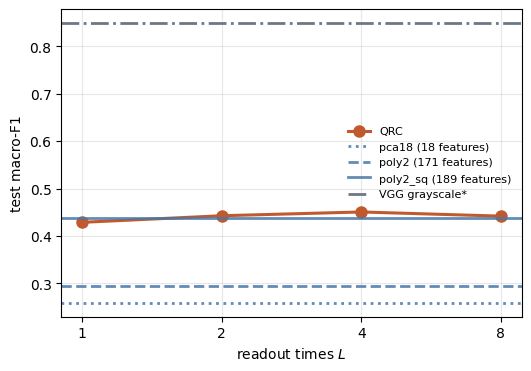

In [7]:
import matplotlib.pyplot as plt

Ls = [1, 2, 4, 8]
f1s = [results[f"qrc_L{L}"]["macro_f1"] for L in Ls]

print(f"{'L':>3}{'dim':>7}{'macro-F1':>11}{'Δ vs L=1':>11}")
for L, f in zip(Ls, f1s):
    print(f"{L:>3}{L * N_OBS:>7}{f:>11.4f}{f - f1s[0]:>+11.4f}")

fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)
ax.plot(Ls, f1s, "o-", color="#c05a2e", linewidth=2.2, markersize=8, label="QRC")
for name, style in (("pca18", ":"), ("poly2", "--"), ("poly2_sq", "-")):
    ax.axhline(results[name]["macro_f1"], linestyle=style, color="#4878a8",
               linewidth=2, alpha=0.85,
               label=f"{name} ({ARMS[name]['dim']} features)")
if "vgg_gray" in correct:
    ax.axhline(f1_score(y["test"], vgg["vgg_gray"], average="macro"),
               linestyle="-.", color="#6b7885", linewidth=2, label="VGG grayscale*")
ax.set_xscale("log", base=2)
ax.set_xticks(Ls, [str(L) for L in Ls])
ax.set_xlabel("readout times $L$")
ax.set_ylabel("test macro-F1")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIG_DIR / "qrc_classification_L_curve.pdf")
fig.savefig(FIG_DIR / "qrc_classification_L_curve.png", dpi=130)
plt.show()

## Per-class

Which land-cover classes gain. This is the only part that speaks the domain's
language rather than the method's.

In [8]:
for name in ("pca18", "poly2_sq", "qrc_L8"):
    print(f"\n--- {name} ---")
    print(classification_report(y["test"], results[name]["pred"],
                                target_names=CATEGORIES, digits=3, zero_division=0))

print(f"{'class':>22}{'pca18':>9}{'poly2_sq':>11}{'qrc_L8':>9}{'Δ qrc-poly2_sq':>16}")
print("-" * 62)
for i, cat in enumerate(CATEGORIES):
    m = y["test"] == i
    a, b, c = (correct[n][m].mean() for n in ("pca18", "poly2_sq", "qrc_L8"))
    print(f"{cat:>22}{a:>9.3f}{b:>11.3f}{c:>9.3f}{c - b:>+16.3f}")


--- pca18 ---
                      precision    recall  f1-score   support

          AnnualCrop      0.259     0.433     0.324       300
              Forest      0.523     0.760     0.620       300
HerbaceousVegetation      0.201     0.290     0.238       300
             Highway      0.349     0.060     0.102       250
          Industrial      0.517     0.596     0.554       250
             Pasture      0.333     0.005     0.010       200
       PermanentCrop      0.400     0.008     0.016       250
         Residential      0.222     0.190     0.205       300
               River      0.345     0.444     0.388       250
             SeaLake      0.119     0.163     0.138       300

            accuracy                          0.307      2700
           macro avg      0.327     0.295     0.259      2700
        weighted avg      0.321     0.307     0.268      2700


--- poly2_sq ---
                      precision    recall  f1-score   support

          AnnualCrop      0.452  

## Save

Per-image predictions and probabilities for every arm, plus the summary and the
tests, so nothing downstream has to refit anything.

In [9]:
np.savez(OUT_DIR / "probe_test_predictions.npz",
         y_true=y["test"], categories=np.array(CATEGORIES),
         **{f"pred_{n}": r["pred"] for n, r in results.items()},
         **{f"prob_{n}": r["prob"] for n, r in results.items()})

summary = dict(
    arms={n: {k: r[k] for k in ("dim", "C", "val_f1", "accuracy", "macro_f1", "bal_acc",
                    "converged", "refit")}
          for n, r in results.items()},
    references={n: dict(accuracy=float(accuracy_score(y["test"], p)),
                        macro_f1=float(f1_score(y["test"], p, average="macro")),
                        bal_acc=float(balanced_accuracy_score(y["test"], p)))
                for n, p in vgg.items()},
    tests=[{k: v for k, v in t.items()} for t in tests],
    n_test=int(len(y["test"])), seed=SEED,
    c_grid=list(map(float, C_GRID)), c_grid_refit=list(map(float, C_GRID_REFIT)),
    max_iter=MAX_ITER, refit=sorted(REFIT),
)
(OUT_DIR / "probe_summary.json").write_text(json.dumps(summary, indent=2))

print(f"saved {OUT_DIR}/probe_test_predictions.npz")
print(f"saved {OUT_DIR}/probe_summary.json")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<30}{p.stat().st_size / 1e6:>8.2f} MB")

saved results/qrc_classification/probe_test_predictions.npz
saved results/qrc_classification/probe_summary.json
  probe_summary.json                0.00 MB
  probe_summary_run1.json           0.00 MB
  probe_test_predictions.npz        1.69 MB
  probe_test_predictions_run1.npz    1.69 MB
